In [1]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv(
    "Data/BTC_historical_INR.csv",
    parse_dates=["Date"]
)

df = df[["Date", "Close"]].dropna()
df = df.sort_values("Date")

In [3]:
df_prophet = df.rename(columns={
    "Date": "ds",
    "Close": "y"
})

In [4]:
split_ratio = 0.8
split_index = int(len(df_prophet) * split_ratio)

train = df_prophet.iloc[:split_index]
test  = df_prophet.iloc[split_index:]

In [5]:
model = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

In [6]:
model.fit(train)

15:07:32 - cmdstanpy - INFO - Chain [1] start processing
15:07:32 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
future = model.make_future_dataframe(
    periods=len(test),
    freq="D"
)

In [8]:
forecast = model.predict(future)

In [9]:
predictions = forecast.iloc[-len(test):]["yhat"].values
actual = test["y"].values

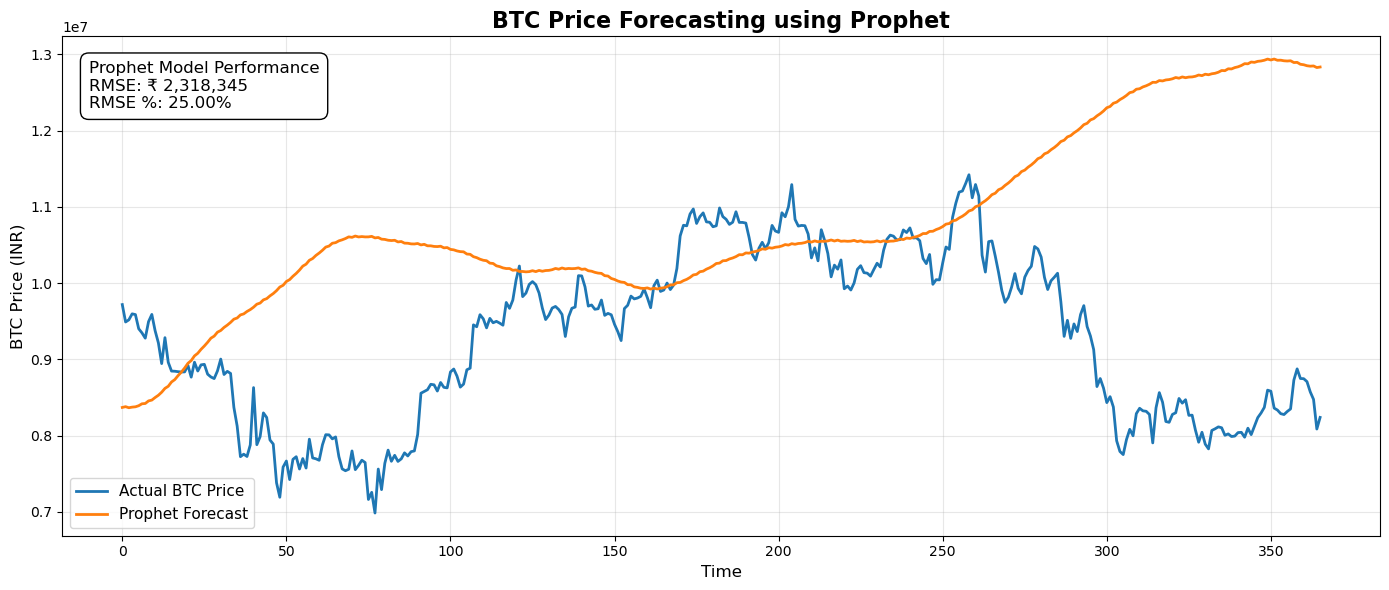

In [10]:
# Prophet predictions usually in dataframe with column 'yhat'
predictions = forecast['yhat'][-len(test):].values
actual = test['y'].values   # adjust if your test column name differs

# --- METRICS ---
rmse = np.sqrt(mean_squared_error(actual, predictions))
rmse_percent = (rmse / np.mean(actual)) * 100

inr_rmse_on_fig = f"₹ {rmse:,.0f}"
percent_rmse_on_fig = f"{rmse_percent:.2f}%"

# --- PLOT ---
plt.figure(figsize=(14,6))

plt.plot(actual, label='Actual BTC Price', linewidth=2)
plt.plot(predictions, label='Prophet Forecast', linewidth=2)

plt.title('BTC Price Forecasting using Prophet', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('BTC Price (INR)', fontsize=12)

# 📦 METRICS BOX
metrics_text = f"Prophet Model Performance\nRMSE: {inr_rmse_on_fig}\nRMSE %: {percent_rmse_on_fig}"

plt.text(
    0.02, 0.95, metrics_text,
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", facecolor='white', edgecolor='black')
)

plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()

# 💾 HIGH RES SAVE
plt.savefig("BTC_Prophet_Forecast.png", dpi=300, bbox_inches='tight')

plt.show()

### Note : “This Prophet model captures the long-term trend of BTC prices but does not model short-term volatility, which results in higher RMSE.”